# TP N°2 Regresión Logística: Horas de estudio para aprobar un exámen
## 1. Modificar el conjunto de Datos
Modificar manualmente los datos del ejercicio planteado en el link: https://www.iartificial.net/como-usar-regresion-logistica-en-python/:

Datos originales: (Horas, aprueba) = (0.50, 0) (0.75, 0) (1.00, 0) (1.25, 0) (1.50, 0) (1.75, 0) (1.75, 1) (2.00, 0) (2.25, 1) (2.50, 0) (2.75, 1) (3.00, 0) (3.25, 1) (3.50, 0) (4.00, 1) (4.25, 1) (4.50, 1) (4.75, 1) (5.00, 1) (5.50, 1)

en donde el Tag de salida 0 indica que el alumno no aprobó y con un 1 que el alumno aprobó, tal que la cantidad de horas de estudio no se solapen con los alumnos que aprueban y los que no aprueban. Por ejemplo:

![img](TPN2.1.JPG)

Carga de datos

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


horas_estudio = np.array([0.50, 0.75, 1.00,1.25, 1.50, 1.75, 2.00, 2.10, 2.50, 2.50, 3.75, 3.85, 3.90,  4.10,  4.20, 4.25, 4.50, 4.75, 5.00, 5.50]).reshape(-1,1)
aprueba = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])



Text(0, 0.5, 'Aprueba (1) / No aprueba (0)')

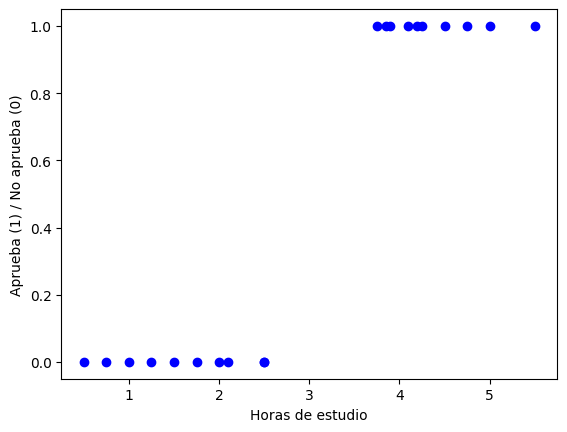

In [ ]:
# Graficar los datos
plt.scatter(horas_estudio, aprueba, color='blue', label='Datos')
plt.xlabel('Horas de estudio')
plt.ylabel('Aprueba (1) / No aprueba (0)')

## 2. Plantear un modelo de Regresión Lineal
Ahora con los datos separables linealmente, plantear una Regresión Lineal y graficar los datos horas vs aprobar y la recta modelada por la Regresión Lineal.

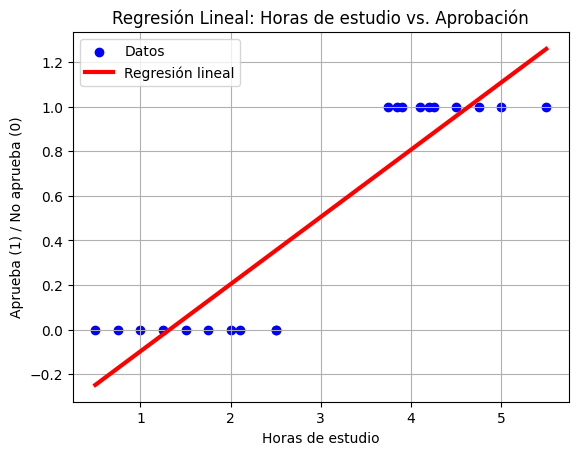

In [ ]:
# PUNTO 2 HACER LA REGRESION LINEAL
regresion_lineal = LinearRegression()
regresion_lineal.fit(horas_estudio.reshape(-1, 1), aprueba)

# Graficar los datos
plt.scatter(horas_estudio, aprueba, color='blue', label='Datos')
plt.xlabel('Horas de estudio')
plt.ylabel('Aprueba (1) / No aprueba (0)')

# Graficar la recta modelada por la regresión lineal
plt.plot(horas_estudio, regresion_lineal.predict(horas_estudio.reshape(-1, 1)), color='red', linewidth=3, label='Regresión lineal')

plt.legend()
plt.title('Regresión Lineal: Horas de estudio vs. Aprobación')
plt.grid(True)
plt.show()

* **PREGUNTA**: Siendo los datos separables linealmente ¿Porque la recta del modelo lineal no nos da como resultado una recta así? de esta manera tendríamos separados los alumnos aprobados y no aprobados. Ayuda !!!! recordar como trabaja la Regresión Lineal y la Regresión Logística.

## 3. Plantear una Regresión Logística
Plantear una Regresión Logística y graficar los datos horas vs aprobar y la función Sigmoide.

In [ ]:
from sklearn.linear_model import LogisticRegression

# Ajustar una regresión logística
regresion_logistica = LogisticRegression()
regresion_logistica.fit(horas_estudio.reshape(-1, 1), aprueba)

LogisticRegression()

In [ ]:
regresion_logistica.coef_

array([[1.89156955]])

In [ ]:
regresion_logistica.intercept_

array([-5.75770183])

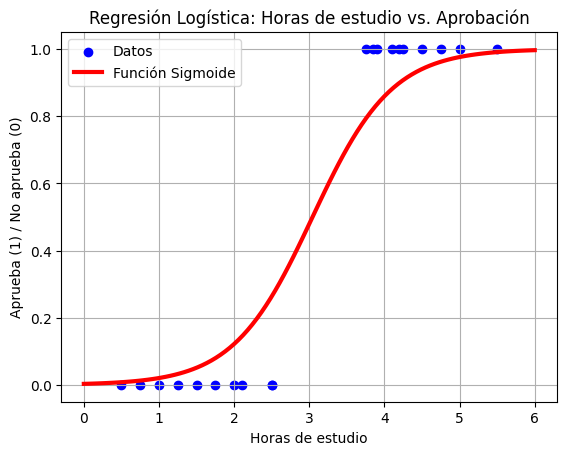

In [ ]:
# Gráficos
plt.scatter(horas_estudio, aprueba, color='blue', label='Datos')
plt.xlabel('Horas de estudio')
plt.ylabel('Aprueba (1) / No aprueba (0)')

# Gráfico de la función sigmoide
x_values = np.linspace(0, 6, 100)
y_values = 1 / (1 + np.exp(-regresion_logistica.coef_[0][0] * x_values - regresion_logistica.intercept_[0]))
plt.plot(x_values, y_values, color='red', linewidth=3, label='Función Sigmoide')

plt.legend()
plt.title('Regresión Logística: Horas de estudio vs. Aprobación')
plt.grid(True)
plt.show()


## 4. Hacer un gráfico que contenga dos funciones Sigmoide (una de los datos originales y otra con éstos nuevos datos)
Superponer en un mismo gráfico los datos originales del link y los modificados en este notebook como también las dos funciones sigmoides

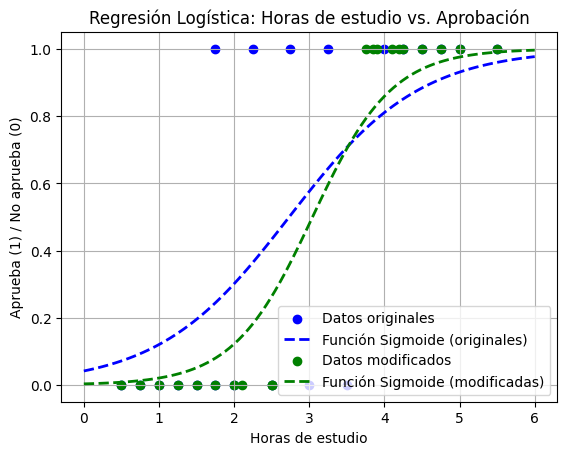

In [ ]:
# datos originales
horas_originales = np.array([0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 1.75, 2.0, 2.25, 2.5, 2.75, 3.0, 3.25, 3.5, 4.0, 4.25, 4.5, 4.75, 5.0, 5.5]).reshape(-1,1)
aprueba_originales = np.array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1])
# datos modificados
horas_modificadas= np.array([0.50, 0.75, 1.00,1.25, 1.50, 1.75, 2.00, 2.10, 2.50, 2.50, 3.75, 3.85, 3.90,  4.10,  4.20, 4.25, 4.50, 4.75, 5.00, 5.50]).reshape(-1,1)
aprueba_modificadas= np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

# hago una regresión logística para los datos originales
regresion_logistica_originales = LogisticRegression()
regresion_logistica_originales.fit(horas_originales.reshape(-1, 1), aprueba_originales)

# hago una regresión logística para los datos modificados
regresion_logistica_modificadas = LogisticRegression()
regresion_logistica_modificadas.fit(horas_modificadas.reshape(-1, 1), aprueba_modificadas)

# grafico los originales
plt.scatter(horas_originales, aprueba_originales, color='blue', label='Datos originales')
x_values_originales = np.linspace(0, 6, 100)
y_values_originales = 1 / (1 + np.exp(-regresion_logistica_originales.coef_[0][0] * x_values_originales - regresion_logistica_originales.intercept_[0]))
plt.plot(x_values_originales, y_values_originales, color='blue', linestyle='--', linewidth=2, label='Función Sigmoide (originales)')

# grafico aca los datos modificados
plt.scatter(horas_modificadas, aprueba_modificadas, color='green', label='Datos modificados')
x_values_modificadas = np.linspace(0, 6, 100)
y_values_modificadas = 1 / (1 + np.exp(-regresion_logistica_modificadas.coef_[0][0] * x_values_modificadas - regresion_logistica_modificadas.intercept_[0]))
plt.plot(x_values_modificadas, y_values_modificadas, color='green', linestyle='--', linewidth=2, label='Función Sigmoide (modificadas)')

plt.xlabel('Horas de estudio')
plt.ylabel('Aprueba (1) / No aprueba (0)')
plt.legend()
plt.title('Regresión Logística: Horas de estudio vs. Aprobación')
plt.grid(True)
plt.show()


* **PREGUNTA**: ¿que puede decir de las 2 curvas?

Que las funciones sigmoides van cambiando cuando los datos cambian y se van ajustando a la mejor función sigmoide que minimice el error, es decir se van "achatando" o "estirando", también se puede ver que el valor umbral de 0.5 es diferente para ambas. Por lo tanto, la sigmoide que me permite cometer menos error es la sigmoide de color verde.

## 5. Ejercicio extra
Graficar en un mismo gráfico las recta de Regresión Lineal y las fronteras de decisión de los 2 modelos de Regresión Logística

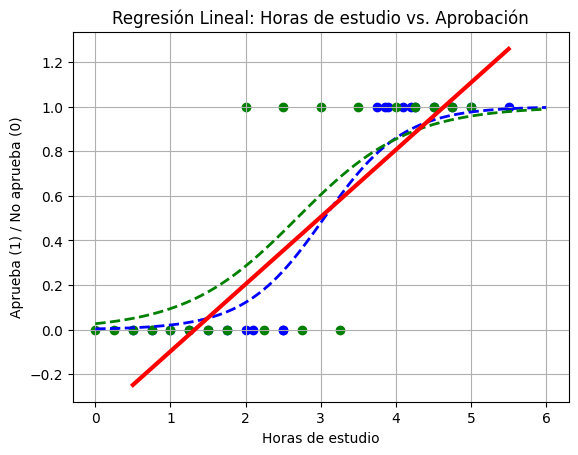

In [ ]:
# grafico los originales
plt.scatter(horas_originales, aprueba_originales, color='blue', label='Datos originales')
x_values_originales = np.linspace(0, 6, 100)
y_values_originales = 1 / (1 + np.exp(-regresion_logistica_originales.coef_[0][0] * x_values_originales - regresion_logistica_originales.intercept_[0]))
plt.plot(x_values_originales, y_values_originales, color='blue', linestyle='--', linewidth=2, label='Función Sigmoide (originales)')

# grafico aca los datos modificados
plt.scatter(horas_modificadas, aprueba_modificadas, color='green', label='Datos modificados')
x_values_modificadas = np.linspace(0, 6, 100)
y_values_modificadas = 1 / (1 + np.exp(-regresion_logistica_modificadas.coef_[0][0] * x_values_modificadas - regresion_logistica_modificadas.intercept_[0]))
plt.plot(x_values_modificadas, y_values_modificadas, color='green', linestyle='--', linewidth=2, label='Función Sigmoide (modificadas)')

plt.xlabel('Horas de estudio')
plt.ylabel('Aprueba (1) / No aprueba (0)')
#plt.legend()
plt.title('Regresión Logística: Horas de estudio vs. Aprobación')
plt.grid(True)



# Graficar la recta modelada por la regresión lineal
plt.plot(horas_estudio, regresion_lineal.predict(horas_estudio.reshape(-1, 1)), color='red', linewidth=3, label='Regresión lineal')


plt.title('Regresión Lineal: Horas de estudio vs. Aprobación')
plt.grid(True)